<a href="https://colab.research.google.com/github/mmallare/ECGR4106/blob/main/ecgr4106_homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torchsummary

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import random
from torchsummary import summary
from torch.utils.data import random_split, DataLoader

In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
#Normalization values
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=train_transform)
train_set, val_set = random_split(full_train, [45000, 5000],
                                   generator=torch.Generator().manual_seed(SEED))

val_set.dataset.transform = test_transform

test_set = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=test_transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=128, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=128, shuffle=False, num_workers=2)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

Train: 45000 | Val: 5000 | Test: 10000


Problem 1A

In [ ]:
class ModifiedAlexNet(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.0):
        super(ModifiedAlexNet, self).__init__()
        self.features = nn.Sequential(
            #Block 1: 3x3 conv instead of 11x11, no aggressive stride
            #Input: (3, 32, 32) → Output: (64, 32, 32)
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Block 2
            #Input: (64, 16, 16) → Output: (128, 16, 16)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            #Pool: (128, 16, 16) → (128, 8, 8)
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Input: (128, 8, 8) → Output: (256, 8, 8)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
Input: (256, 8, 8) → Output: (256, 8, 8)
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            #Input: (256, 8, 8) → Output: (128, 8, 8)
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(128 * 8 * 8, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [ ]:
model = ModifiedAlexNet(num_classes=10, dropout_rate=0.0).to(device)
summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 8, 8]         295,168
              ReLU-8            [-1, 256, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         590,080
             ReLU-10            [-1, 256, 8, 8]               0
           Conv2d-11            [-1, 128, 8, 8]         295,040
             ReLU-12            [-1, 128, 8, 8]               0
          Dropout-13                 [-1, 8192]               0
           Linear-14                 [-

In [ ]:
#Added for comparison with Problem 2A

import time

model.eval()
start = time.time()

# Run one full pass through the train loader
running_loss = 0.0
model.train()
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

alexnet_time_per_epoch = time.time() - start
print(f"AlexNet approx time per epoch: {alexnet_time_per_epoch:.1f}s")

AlexNet approx time per epoch: 21.4s


In [ ]:
#Training
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

#Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=30):
    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)


        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        scheduler.step()

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, val_accuracies

In [ ]:
#Run training
train_losses, val_losses, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=30
)

Epoch [1/30] Train Loss: 2.1415 | Val Loss: 1.7432 | Val Acc: 34.12%
Epoch [2/30] Train Loss: 1.5580 | Val Loss: 1.4259 | Val Acc: 47.04%
Epoch [3/30] Train Loss: 1.3086 | Val Loss: 1.1521 | Val Acc: 57.64%
Epoch [4/30] Train Loss: 1.1072 | Val Loss: 1.0549 | Val Acc: 61.82%
Epoch [5/30] Train Loss: 0.9467 | Val Loss: 0.9736 | Val Acc: 65.12%
Epoch [6/30] Train Loss: 0.8224 | Val Loss: 0.8382 | Val Acc: 69.36%
Epoch [7/30] Train Loss: 0.7201 | Val Loss: 0.7733 | Val Acc: 72.20%
Epoch [8/30] Train Loss: 0.6422 | Val Loss: 0.7354 | Val Acc: 73.54%
Epoch [9/30] Train Loss: 0.5589 | Val Loss: 0.7832 | Val Acc: 73.06%
Epoch [10/30] Train Loss: 0.5004 | Val Loss: 0.6738 | Val Acc: 76.40%
Epoch [11/30] Train Loss: 0.3525 | Val Loss: 0.5982 | Val Acc: 79.52%
Epoch [12/30] Train Loss: 0.2979 | Val Loss: 0.6212 | Val Acc: 79.52%
Epoch [13/30] Train Loss: 0.2458 | Val Loss: 0.6245 | Val Acc: 80.12%
Epoch [14/30] Train Loss: 0.1975 | Val Loss: 0.6458 | Val Acc: 80.20%
Epoch [15/30] Train Loss: 0.1

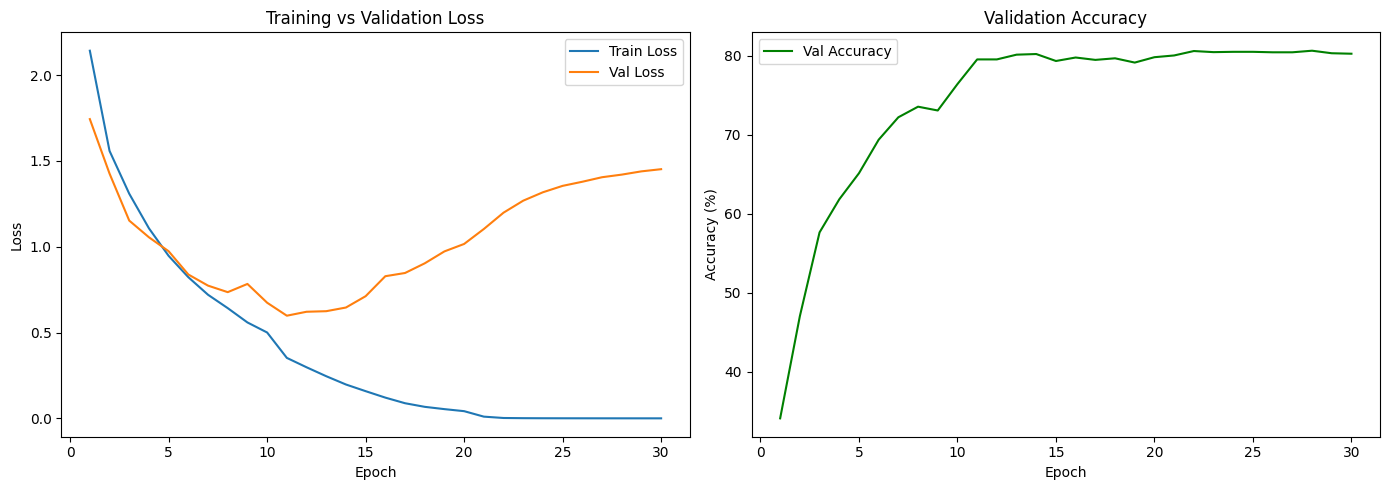

Test Accuracy: 80.51%


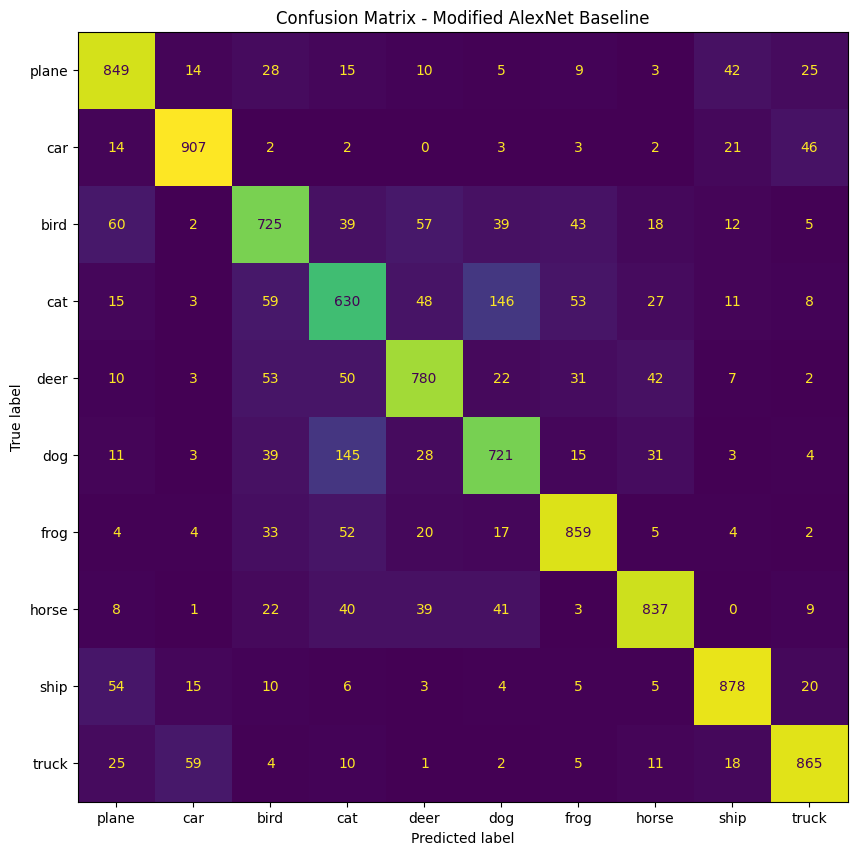

In [ ]:
#Plot
epochs_range = range(1, 31)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Loss curves
ax1.plot(epochs_range, train_losses, label='Train Loss')
ax1.plot(epochs_range, val_losses,   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()

#Accuracy curve
ax2.plot(epochs_range, val_accuracies, label='Val Accuracy', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('alexnet_baseline_curves.png', dpi=150)
plt.show()

#Accuracy
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

test_acc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.2f}%")

#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, colorbar=False)
plt.title('Confusion Matrix - Modified AlexNet Baseline')
plt.savefig('alexnet_confusion_matrix.png', dpi=150)
plt.show()

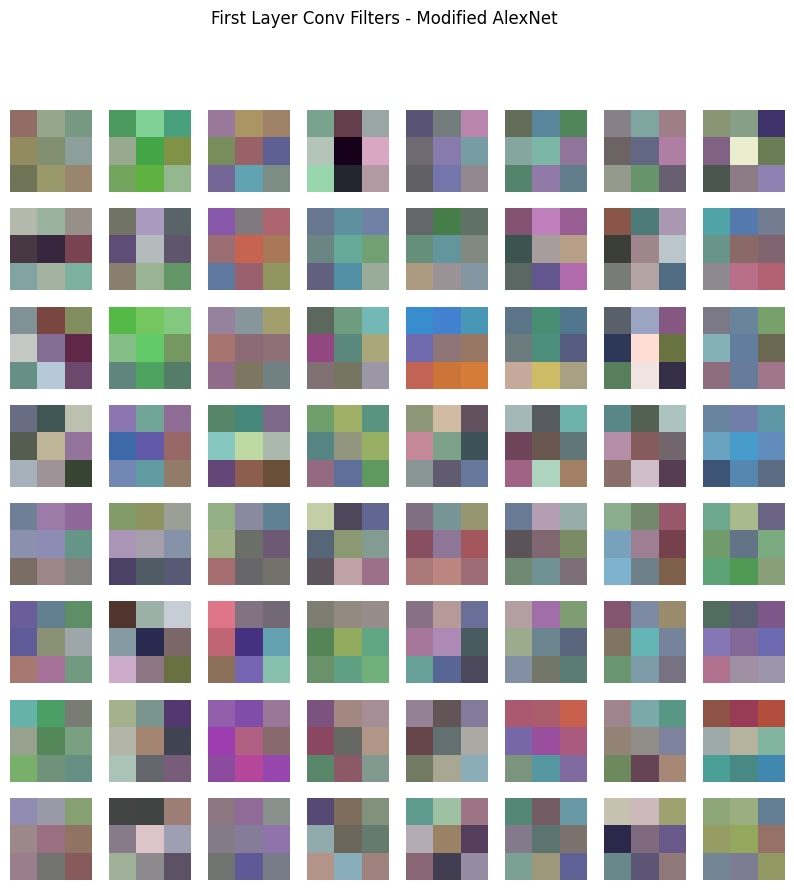

In [ ]:
#Filter Visualization

filters = model.features[0].weight.data.clone().cpu()
filters = filters - filters.min()
filters = filters / filters.max()

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < filters.shape[0]:
        ax.imshow(filters[i].permute(1, 2, 0).clamp(0,1))
    ax.axis('off')

plt.suptitle('First Layer Conv Filters - Modified AlexNet')
plt.savefig('alexnet_filters.png', dpi=150)
plt.show()

Problem 1B

In [ ]:
#Training with dropout (p=0.3)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

model_d03 = ModifiedAlexNet(num_classes=10, dropout_rate=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_d03 = optim.SGD(model_d03.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler_d03 = optim.lr_scheduler.StepLR(optimizer_d03, step_size=10, gamma=0.5)

print("Training with dropout p=0.3.")
tl_03, vl_03, va_03 = train_model(
    model_d03, train_loader, val_loader,
    criterion, optimizer_d03, scheduler_d03, epochs=30
)

Training with dropout p=0.3.
Epoch [1/30] Train Loss: 2.1869 | Val Loss: 1.8616 | Val Acc: 29.56%
Epoch [2/30] Train Loss: 1.6162 | Val Loss: 1.4193 | Val Acc: 47.32%
Epoch [3/30] Train Loss: 1.3490 | Val Loss: 1.2644 | Val Acc: 54.24%
Epoch [4/30] Train Loss: 1.1532 | Val Loss: 1.0984 | Val Acc: 61.28%
Epoch [5/30] Train Loss: 0.9865 | Val Loss: 0.9176 | Val Acc: 67.24%
Epoch [6/30] Train Loss: 0.8748 | Val Loss: 0.8461 | Val Acc: 69.76%
Epoch [7/30] Train Loss: 0.7606 | Val Loss: 0.7247 | Val Acc: 73.78%
Epoch [8/30] Train Loss: 0.6834 | Val Loss: 0.7210 | Val Acc: 74.02%
Epoch [9/30] Train Loss: 0.6197 | Val Loss: 0.6950 | Val Acc: 74.90%
Epoch [10/30] Train Loss: 0.5515 | Val Loss: 0.6660 | Val Acc: 76.12%
Epoch [11/30] Train Loss: 0.4298 | Val Loss: 0.5862 | Val Acc: 79.38%
Epoch [12/30] Train Loss: 0.3839 | Val Loss: 0.5801 | Val Acc: 79.74%
Epoch [13/30] Train Loss: 0.3480 | Val Loss: 0.5981 | Val Acc: 79.74%
Epoch [14/30] Train Loss: 0.3193 | Val Loss: 0.5743 | Val Acc: 79.70%


In [ ]:
#Training with dropout (p=0.5)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

model_d05 = ModifiedAlexNet(num_classes=10, dropout_rate=0.5).to(device)
optimizer_d05 = optim.SGD(model_d05.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler_d05 = optim.lr_scheduler.StepLR(optimizer_d05, step_size=10, gamma=0.5)

print("Training with dropout p=0.5.")
tl_05, vl_05, va_05 = train_model(
    model_d05, train_loader, val_loader,
    criterion, optimizer_d05, scheduler_d05, epochs=30
)

Training with dropout p=0.5.
Epoch [1/30] Train Loss: 2.2099 | Val Loss: 1.8779 | Val Acc: 30.00%
Epoch [2/30] Train Loss: 1.6603 | Val Loss: 1.4438 | Val Acc: 46.68%
Epoch [3/30] Train Loss: 1.3887 | Val Loss: 1.2611 | Val Acc: 53.52%
Epoch [4/30] Train Loss: 1.1954 | Val Loss: 1.0918 | Val Acc: 60.62%
Epoch [5/30] Train Loss: 1.0426 | Val Loss: 0.9588 | Val Acc: 65.20%
Epoch [6/30] Train Loss: 0.9184 | Val Loss: 0.8677 | Val Acc: 67.84%
Epoch [7/30] Train Loss: 0.8119 | Val Loss: 0.7791 | Val Acc: 72.04%
Epoch [8/30] Train Loss: 0.7390 | Val Loss: 0.7314 | Val Acc: 73.76%
Epoch [9/30] Train Loss: 0.6721 | Val Loss: 0.7271 | Val Acc: 74.02%
Epoch [10/30] Train Loss: 0.6068 | Val Loss: 0.6900 | Val Acc: 75.40%
Epoch [11/30] Train Loss: 0.4852 | Val Loss: 0.5978 | Val Acc: 79.22%
Epoch [12/30] Train Loss: 0.4388 | Val Loss: 0.5773 | Val Acc: 80.04%
Epoch [13/30] Train Loss: 0.4060 | Val Loss: 0.5896 | Val Acc: 80.00%
Epoch [14/30] Train Loss: 0.3700 | Val Loss: 0.6142 | Val Acc: 79.02%


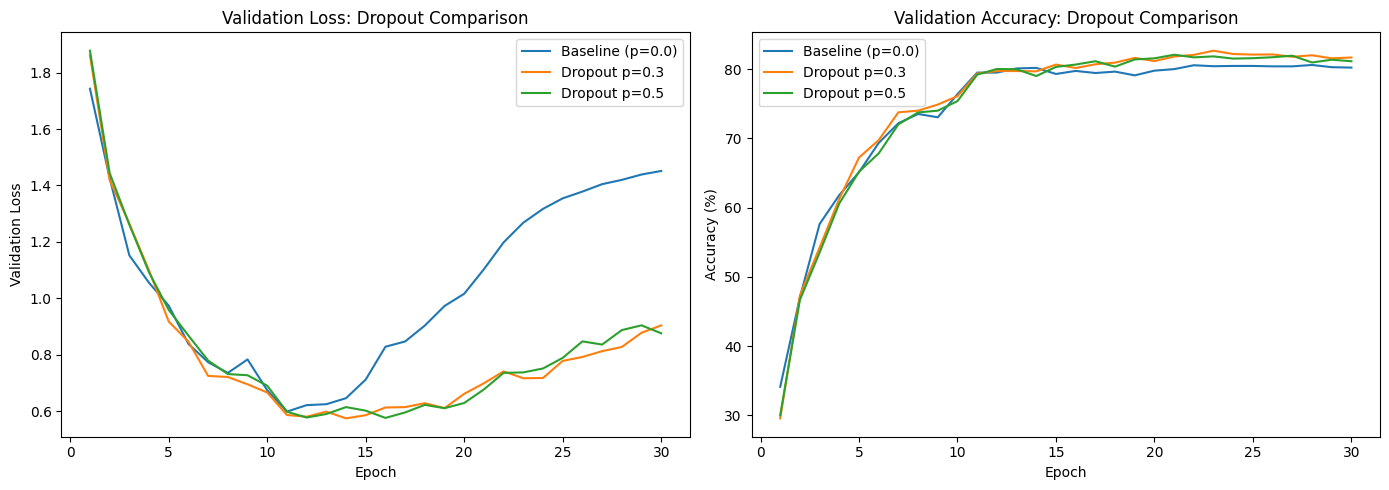

Baseline  (p=0.0): 80.51%
Dropout   (p=0.3): 80.73%
Dropout   (p=0.5): 80.98%


In [ ]:
#Comparison Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Validation loss comparison
ax1.plot(epochs_range, val_losses, label='Baseline (p=0.0)')
ax1.plot(epochs_range, vl_03,      label='Dropout p=0.3')
ax1.plot(epochs_range, vl_05,      label='Dropout p=0.5')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Validation Loss')
ax1.set_title('Validation Loss: Dropout Comparison')
ax1.legend()

# Validation accuracy comparison
ax2.plot(epochs_range, val_accuracies, label='Baseline (p=0.0)')
ax2.plot(epochs_range, va_03,          label='Dropout p=0.3')
ax2.plot(epochs_range, va_05,          label='Dropout p=0.5')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy: Dropout Comparison')
ax2.legend()

plt.tight_layout()
plt.savefig('alexnet_dropout_comparison.png', dpi=150)
plt.show()

#Accuracy
acc_base = evaluate(model,     test_loader)
acc_d03  = evaluate(model_d03, test_loader)
acc_d05  = evaluate(model_d05, test_loader)

print(f"Baseline  (p=0.0): {acc_base:.2f}%")
print(f"Dropout   (p=0.3): {acc_d03:.2f}%")
print(f"Dropout   (p=0.5): {acc_d05:.2f}%")

Problem 2A

In [ ]:
#VGG-11
class AdaptedVGG11(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.0):
        super(AdaptedVGG11, self).__init__()

        self.features = nn.Sequential(
            #Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            #Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            #Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        #After features
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(512 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [ ]:
vgg_model = AdaptedVGG11(num_classes=10, dropout_rate=0.0).to(device)
summary(vgg_model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 8, 8]         295,168
              ReLU-8            [-1, 256, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         590,080
             ReLU-10            [-1, 256, 8, 8]               0
           Conv2d-11            [-1, 512, 8, 8]       1,180,160
             ReLU-12            [-1, 512, 8, 8]               0
           Conv2d-13            [-1, 512, 8, 8]       2,359,808
             ReLU-14            [-1, 51

In [ ]:
#Training
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

vgg_baseline = AdaptedVGG11(num_classes=10, dropout_rate=0.0).to(device)
criterion     = nn.CrossEntropyLoss()
optimizer_vgg = optim.SGD(vgg_baseline.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler_vgg = optim.lr_scheduler.StepLR(optimizer_vgg, step_size=10, gamma=0.5)

import time
start = time.time()

print("Training VGG-11 Baseline...")
vgg_tl, vgg_vl, vgg_va = train_model(
    vgg_baseline, train_loader, val_loader,
    criterion, optimizer_vgg, scheduler_vgg, epochs=30
)

vgg_time = (time.time() - start) / 30  # avg seconds per epoch
print(f"\nAvg time per epoch: {vgg_time:.1f}s")

Training VGG-11 Baseline...
Epoch [1/30] Train Loss: 2.3029 | Val Loss: 2.3031 | Val Acc: 9.42%
Epoch [2/30] Train Loss: 2.3029 | Val Loss: 2.3029 | Val Acc: 9.76%
Epoch [3/30] Train Loss: 2.3028 | Val Loss: 2.3033 | Val Acc: 9.42%
Epoch [4/30] Train Loss: 2.3027 | Val Loss: 2.3027 | Val Acc: 9.42%
Epoch [5/30] Train Loss: 2.3022 | Val Loss: 2.3016 | Val Acc: 9.76%
Epoch [6/30] Train Loss: 2.1628 | Val Loss: 1.8887 | Val Acc: 25.12%
Epoch [7/30] Train Loss: 1.7427 | Val Loss: 1.5754 | Val Acc: 38.70%
Epoch [8/30] Train Loss: 1.4945 | Val Loss: 1.3624 | Val Acc: 49.04%
Epoch [9/30] Train Loss: 1.2984 | Val Loss: 1.1418 | Val Acc: 58.54%
Epoch [10/30] Train Loss: 1.1187 | Val Loss: 1.0904 | Val Acc: 61.22%
Epoch [11/30] Train Loss: 0.9089 | Val Loss: 0.8895 | Val Acc: 68.04%
Epoch [12/30] Train Loss: 0.8297 | Val Loss: 0.8624 | Val Acc: 68.38%
Epoch [13/30] Train Loss: 0.7675 | Val Loss: 0.8288 | Val Acc: 70.36%
Epoch [14/30] Train Loss: 0.6934 | Val Loss: 0.7892 | Val Acc: 71.84%
Epoch 

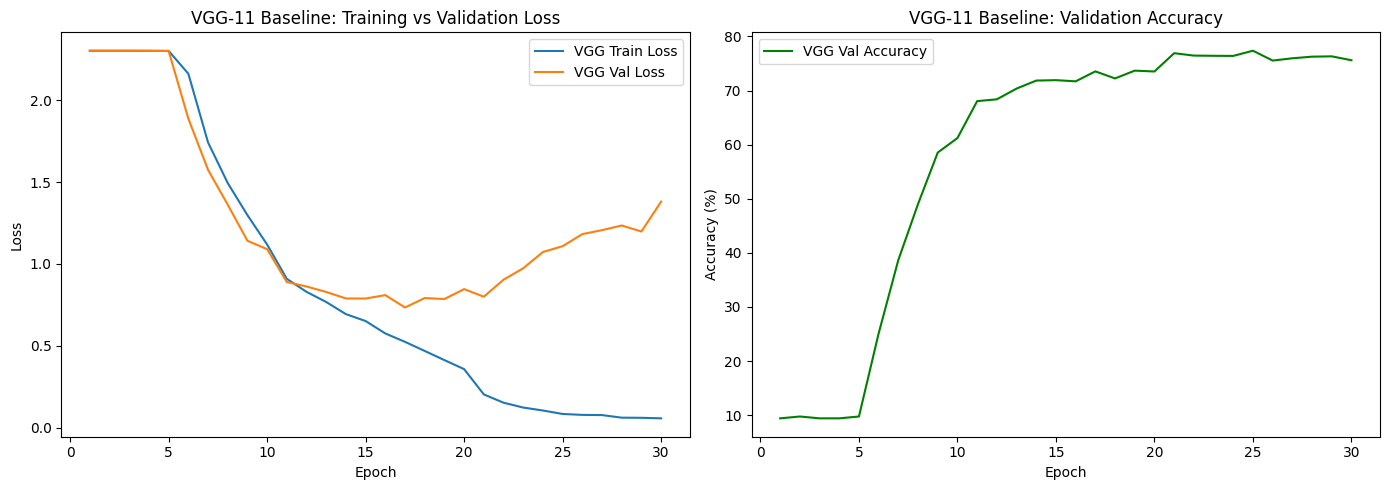

In [ ]:
#Validation Plots
epochs_range = range(1, 31)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, vgg_tl, label='VGG Train Loss')
ax1.plot(epochs_range, vgg_vl, label='VGG Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('VGG-11 Baseline: Training vs Validation Loss')
ax1.legend()

ax2.plot(epochs_range, vgg_va, label='VGG Val Accuracy', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('VGG-11 Baseline: Validation Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('vgg_baseline_curves.png', dpi=150)
plt.show()

VGG-11 Baseline Test Accuracy: 75.17%


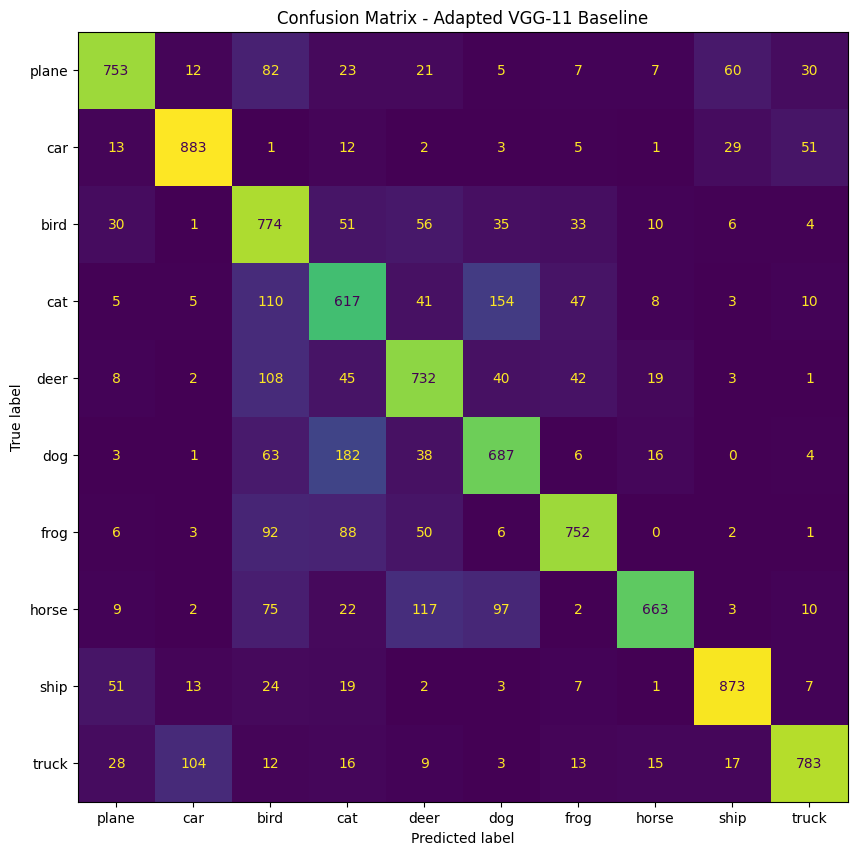

In [ ]:
#Accuracy and Confusion Matrix
vgg_test_acc = evaluate(vgg_baseline, test_loader)
print(f"VGG-11 Baseline Test Accuracy: {vgg_test_acc:.2f}%")

all_preds, all_labels = [], []
vgg_baseline.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = vgg_baseline(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, colorbar=False)
plt.title('Confusion Matrix - Adapted VGG-11 Baseline')
plt.savefig('vgg_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
#Comparison with AlexNet
alexnet_time_per_epoch = 21.4

print("=" * 55)
print(f"{'Model':<20} {'Params':>10} {'Test Acc':>10} {'Time/Epoch':>12}")
print("=" * 55)
print(f"{'Modified AlexNet':<20} {'10.18M':>10} {'80.51%':>10} {alexnet_time_per_epoch:>11.1f}s")
print(f"{'Adapted VGG-11':<20} {'18.14M':>10} {vgg_test_acc:>9.2f}% {vgg_time:>11.1f}s")
print("=" * 55)

Model                    Params   Test Acc   Time/Epoch
Modified AlexNet         10.18M     80.51%        21.4s
Adapted VGG-11           18.14M     75.17%        19.1s


Problem 2B


In [ ]:
#Dropout p=0.3
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

vgg_d03 = AdaptedVGG11(num_classes=10, dropout_rate=0.3).to(device)
opt_d03 = optim.SGD(vgg_d03.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
sch_d03 = optim.lr_scheduler.StepLR(opt_d03, step_size=10, gamma=0.5)

print("Training VGG-11 dropout p=0.3...")
vgg_tl_03, vgg_vl_03, vgg_va_03 = train_model(
    vgg_d03, train_loader, val_loader,
    criterion, opt_d03, sch_d03, epochs=30
)

Training VGG-11 dropout p=0.3...
Epoch [1/30] Train Loss: 2.3029 | Val Loss: 2.3031 | Val Acc: 9.42%
Epoch [2/30] Train Loss: 2.3029 | Val Loss: 2.3029 | Val Acc: 9.76%
Epoch [3/30] Train Loss: 2.3028 | Val Loss: 2.3033 | Val Acc: 9.42%
Epoch [4/30] Train Loss: 2.3027 | Val Loss: 2.3026 | Val Acc: 9.42%
Epoch [5/30] Train Loss: 2.3018 | Val Loss: 2.2995 | Val Acc: 12.98%
Epoch [6/30] Train Loss: 2.0648 | Val Loss: 1.8417 | Val Acc: 26.20%
Epoch [7/30] Train Loss: 1.7124 | Val Loss: 1.5615 | Val Acc: 39.22%
Epoch [8/30] Train Loss: 1.4780 | Val Loss: 1.5008 | Val Acc: 45.24%
Epoch [9/30] Train Loss: 1.2689 | Val Loss: 1.1406 | Val Acc: 58.70%
Epoch [10/30] Train Loss: 1.0952 | Val Loss: 1.0188 | Val Acc: 63.36%
Epoch [11/30] Train Loss: 0.8977 | Val Loss: 0.8613 | Val Acc: 68.64%
Epoch [12/30] Train Loss: 0.8135 | Val Loss: 0.9535 | Val Acc: 64.92%
Epoch [13/30] Train Loss: 0.7581 | Val Loss: 0.8223 | Val Acc: 70.64%
Epoch [14/30] Train Loss: 0.6786 | Val Loss: 0.8245 | Val Acc: 71.42%


In [ ]:
#Dropout p=0.5
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

vgg_d05 = AdaptedVGG11(num_classes=10, dropout_rate=0.5).to(device)
opt_d05 = optim.SGD(vgg_d05.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
sch_d05 = optim.lr_scheduler.StepLR(opt_d05, step_size=10, gamma=0.5)

print("Training VGG-11 dropout p=0.5...")
vgg_tl_05, vgg_vl_05, vgg_va_05 = train_model(
    vgg_d05, train_loader, val_loader,
    criterion, opt_d05, sch_d05, epochs=30
)

Training VGG-11 dropout p=0.5...
Epoch [1/30] Train Loss: 2.3029 | Val Loss: 2.3031 | Val Acc: 9.42%
Epoch [2/30] Train Loss: 2.3029 | Val Loss: 2.3029 | Val Acc: 9.76%
Epoch [3/30] Train Loss: 2.3028 | Val Loss: 2.3033 | Val Acc: 9.42%
Epoch [4/30] Train Loss: 2.3027 | Val Loss: 2.3027 | Val Acc: 9.42%
Epoch [5/30] Train Loss: 2.3023 | Val Loss: 2.3020 | Val Acc: 9.76%
Epoch [6/30] Train Loss: 2.2011 | Val Loss: 1.9202 | Val Acc: 24.54%
Epoch [7/30] Train Loss: 1.8154 | Val Loss: 1.7209 | Val Acc: 33.04%
Epoch [8/30] Train Loss: 1.5767 | Val Loss: 1.4550 | Val Acc: 44.36%
Epoch [9/30] Train Loss: 1.3844 | Val Loss: 1.2115 | Val Acc: 55.52%
Epoch [10/30] Train Loss: 1.1765 | Val Loss: 1.0664 | Val Acc: 61.20%
Epoch [11/30] Train Loss: 0.9705 | Val Loss: 0.9131 | Val Acc: 66.10%
Epoch [12/30] Train Loss: 0.8799 | Val Loss: 0.9240 | Val Acc: 65.88%
Epoch [13/30] Train Loss: 0.8188 | Val Loss: 0.8452 | Val Acc: 69.66%
Epoch [14/30] Train Loss: 0.7418 | Val Loss: 0.7919 | Val Acc: 71.80%
E

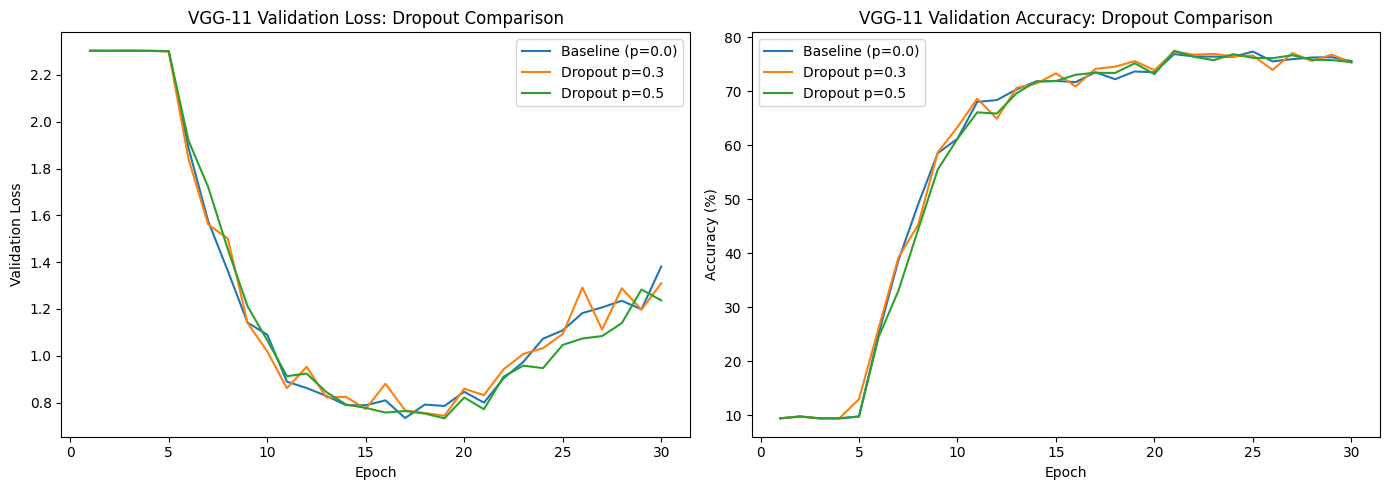

In [ ]:
#Comparison Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, vgg_vl,    label='Baseline (p=0.0)')
ax1.plot(epochs_range, vgg_vl_03, label='Dropout p=0.3')
ax1.plot(epochs_range, vgg_vl_05, label='Dropout p=0.5')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Validation Loss')
ax1.set_title('VGG-11 Validation Loss: Dropout Comparison')
ax1.legend()

ax2.plot(epochs_range, vgg_va,    label='Baseline (p=0.0)')
ax2.plot(epochs_range, vgg_va_03, label='Dropout p=0.3')
ax2.plot(epochs_range, vgg_va_05, label='Dropout p=0.5')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('VGG-11 Validation Accuracy: Dropout Comparison')
ax2.legend()

plt.tight_layout()
plt.savefig('vgg_dropout_comparison.png', dpi=150)
plt.show()

In [ ]:
#Accuracies
vgg_acc_base = evaluate(vgg_baseline, test_loader)
vgg_acc_d03  = evaluate(vgg_d03,      test_loader)
vgg_acc_d05  = evaluate(vgg_d05,      test_loader)

print(f"VGG Baseline  (p=0.0): {vgg_acc_base:.2f}%")
print(f"VGG Dropout   (p=0.3): {vgg_acc_d03:.2f}%")
print(f"VGG Dropout   (p=0.5): {vgg_acc_d05:.2f}%")

# Cross-modelcomparison
print("\n--- Best per model family ---")
print(f"Best AlexNet: 80.98% (p=0.5)")
print(f"Best VGG-11:  {max(vgg_acc_base, vgg_acc_d03, vgg_acc_d05):.2f}%")

VGG Baseline  (p=0.0): 75.17%
VGG Dropout   (p=0.3): 75.41%
VGG Dropout   (p=0.5): 75.83%

--- Best per model family ---
Best AlexNet: 80.98% (p=0.5)
Best VGG-11:  75.83%


Problem 3A

In [ ]:
#Shared by ResNet-11 and ResNet-18
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

In [ ]:
#ResNet-11
class ResNet11(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.0):
        super(ResNet11, self).__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        # Stage 1
        self.stage1 = BasicBlock(64,  64,  stride=1)
        # Stage 2
        self.stage2 = BasicBlock(64,  128, stride=2)
        # Stage 3
        self.stage3 = BasicBlock(128, 256, stride=2)
        # Stage 4
        self.stage4 = BasicBlock(256, 512, stride=2)

        self.pool    = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc      = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
#ResNet-18
class ResNet18(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.0):
        super(ResNet18, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.stage1 = nn.Sequential(
            BasicBlock(64,  64,  stride=1),
            BasicBlock(64,  64,  stride=1)
        )
        self.stage2 = nn.Sequential(
            BasicBlock(64,  128, stride=2),
            BasicBlock(128, 128, stride=1)
        )
        self.stage3 = nn.Sequential(
            BasicBlock(128, 256, stride=2),
            BasicBlock(256, 256, stride=1)
        )
        self.stage4 = nn.Sequential(
            BasicBlock(256, 512, stride=2),
            BasicBlock(512, 512, stride=1)
        )

        self.pool    = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc      = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [ ]:
#Parameter Count
print("ResNet-11:")
resnet11_model = ResNet11(num_classes=10).to(device)
summary(resnet11_model, (3, 32, 32))

print("\nResNet-18:")
resnet18_model = ResNet18(num_classes=10).to(device)
summary(resnet18_model, (3, 32, 32))

ResNet-11:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,864
       BatchNorm2d-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7           [-1, 64, 32, 32]          36,864
       BatchNorm2d-8           [-1, 64, 32, 32]             128
              ReLU-9           [-1, 64, 32, 32]               0
       BasicBlock-10           [-1, 64, 32, 32]               0
           Conv2d-11          [-1, 128, 16, 16]          73,728
      BatchNorm2d-12          [-1, 128, 16, 16]             256
             ReLU-13          [-1, 128, 16, 16]               0
           Conv2d-14        

In [ ]:
#ResNet-11 Training
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

rn11_baseline = ResNet11(num_classes=10, dropout_rate=0.0).to(device)
criterion      = nn.CrossEntropyLoss()
opt_rn11       = optim.SGD(rn11_baseline.parameters(), lr=0.1,
                            momentum=0.9, weight_decay=1e-4)

sch_rn11       = optim.lr_scheduler.CosineAnnealingLR(opt_rn11, T_max=50)

import time
start = time.time()
print("Training ResNet-11 Baseline...")
rn11_tl, rn11_vl, rn11_va = train_model(
    rn11_baseline, train_loader, val_loader,
    criterion, opt_rn11, sch_rn11, epochs=50
)
rn11_time = (time.time() - start) / 50
print(f"\nAvg time per epoch: {rn11_time:.1f}s")

Training ResNet-11 Baseline...
Epoch [1/50] Train Loss: 1.4643 | Val Loss: 1.1873 | Val Acc: 57.68%
Epoch [2/50] Train Loss: 0.9480 | Val Loss: 0.8532 | Val Acc: 68.18%
Epoch [3/50] Train Loss: 0.7057 | Val Loss: 0.8324 | Val Acc: 70.56%
Epoch [4/50] Train Loss: 0.5438 | Val Loss: 0.7992 | Val Acc: 72.64%
Epoch [5/50] Train Loss: 0.4244 | Val Loss: 0.7137 | Val Acc: 76.40%
Epoch [6/50] Train Loss: 0.3235 | Val Loss: 0.6767 | Val Acc: 77.34%
Epoch [7/50] Train Loss: 0.2304 | Val Loss: 0.6488 | Val Acc: 79.56%
Epoch [8/50] Train Loss: 0.1441 | Val Loss: 0.6800 | Val Acc: 79.94%
Epoch [9/50] Train Loss: 0.1048 | Val Loss: 0.7786 | Val Acc: 79.94%
Epoch [10/50] Train Loss: 0.0621 | Val Loss: 0.7299 | Val Acc: 80.58%
Epoch [11/50] Train Loss: 0.0484 | Val Loss: 0.7767 | Val Acc: 81.44%
Epoch [12/50] Train Loss: 0.0243 | Val Loss: 0.7518 | Val Acc: 82.18%
Epoch [13/50] Train Loss: 0.0121 | Val Loss: 0.6917 | Val Acc: 83.54%
Epoch [14/50] Train Loss: 0.0047 | Val Loss: 0.6388 | Val Acc: 84.40

In [ ]:
#ResNet-18 Training
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

rn18_baseline = ResNet18(num_classes=10, dropout_rate=0.0).to(device)
opt_rn18      = optim.SGD(rn18_baseline.parameters(), lr=0.1,
                           momentum=0.9, weight_decay=1e-4)
sch_rn18      = optim.lr_scheduler.CosineAnnealingLR(opt_rn18, T_max=50)

start = time.time()
print("Training ResNet-18 Baseline...")
rn18_tl, rn18_vl, rn18_va = train_model(
    rn18_baseline, train_loader, val_loader,
    criterion, opt_rn18, sch_rn18, epochs=50
)
rn18_time = (time.time() - start) / 50
print(f"\nAvg time per epoch: {rn18_time:.1f}s")

Training ResNet-18 Baseline...
Epoch [1/50] Train Loss: 1.8801 | Val Loss: 1.5794 | Val Acc: 42.46%
Epoch [2/50] Train Loss: 1.3982 | Val Loss: 1.2435 | Val Acc: 55.08%
Epoch [3/50] Train Loss: 1.1636 | Val Loss: 1.1408 | Val Acc: 58.36%
Epoch [4/50] Train Loss: 0.9639 | Val Loss: 0.9551 | Val Acc: 66.48%
Epoch [5/50] Train Loss: 0.7989 | Val Loss: 0.8124 | Val Acc: 70.82%
Epoch [6/50] Train Loss: 0.6608 | Val Loss: 0.7048 | Val Acc: 75.46%
Epoch [7/50] Train Loss: 0.5422 | Val Loss: 0.6533 | Val Acc: 76.78%
Epoch [8/50] Train Loss: 0.4353 | Val Loss: 0.7139 | Val Acc: 75.54%
Epoch [9/50] Train Loss: 0.3426 | Val Loss: 0.7958 | Val Acc: 74.60%
Epoch [10/50] Train Loss: 0.2607 | Val Loss: 0.6977 | Val Acc: 77.62%
Epoch [11/50] Train Loss: 0.1915 | Val Loss: 0.7847 | Val Acc: 76.58%
Epoch [12/50] Train Loss: 0.1365 | Val Loss: 0.8158 | Val Acc: 77.52%
Epoch [13/50] Train Loss: 0.1048 | Val Loss: 0.9022 | Val Acc: 76.80%
Epoch [14/50] Train Loss: 0.0824 | Val Loss: 0.9015 | Val Acc: 78.66

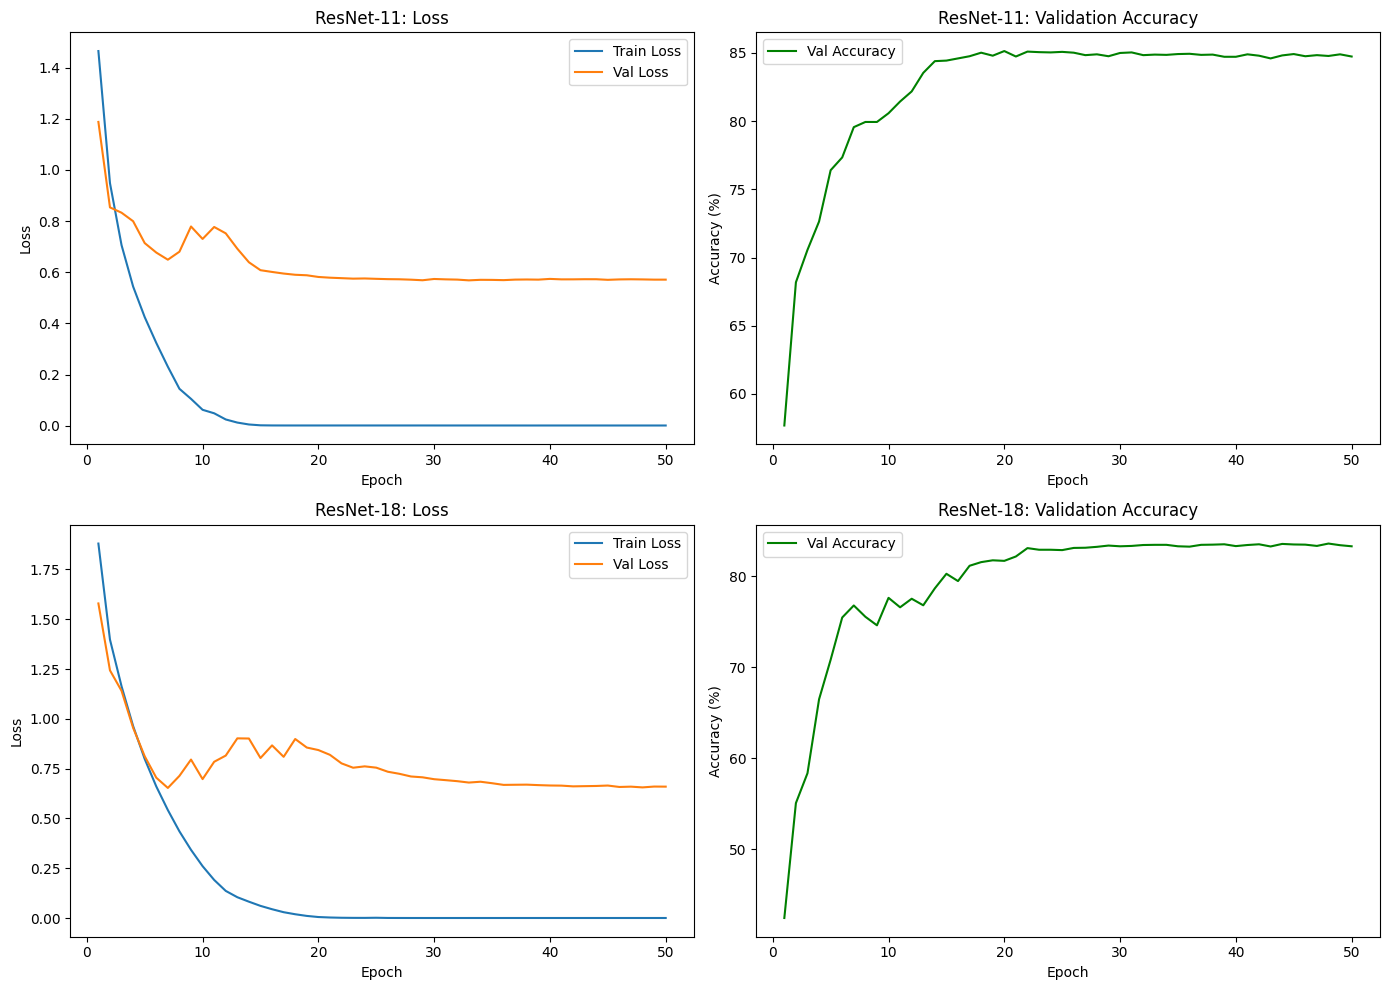

In [ ]:
#Plots
epochs_50 = range(1, 51)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ResNet-11
axes[0,0].plot(epochs_50, rn11_tl, label='Train Loss')
axes[0,0].plot(epochs_50, rn11_vl, label='Val Loss')
axes[0,0].set_title('ResNet-11: Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()

axes[0,1].plot(epochs_50, rn11_va, color='green', label='Val Accuracy')
axes[0,1].set_title('ResNet-11: Validation Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].legend()

# ResNet-18
axes[1,0].plot(epochs_50, rn18_tl, label='Train Loss')
axes[1,0].plot(epochs_50, rn18_vl, label='Val Loss')
axes[1,0].set_title('ResNet-18: Loss')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()

axes[1,1].plot(epochs_50, rn18_va, color='green', label='Val Accuracy')
axes[1,1].set_title('ResNet-18: Validation Accuracy')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('resnet_baseline_curves.png', dpi=150)
plt.show()

ResNet-11 Baseline Test Accuracy: 84.13%
ResNet-18 Baseline Test Accuracy: 82.92%


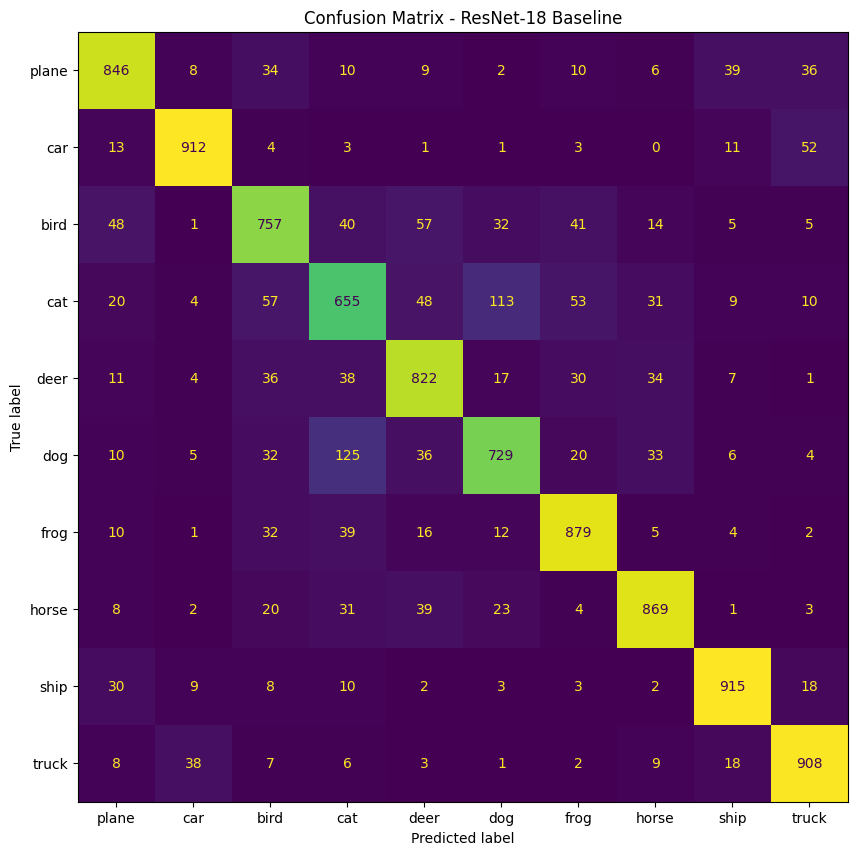

In [ ]:
#Accuracy & Confusion Matrix
rn11_test_acc = evaluate(rn11_baseline, test_loader)
rn18_test_acc = evaluate(rn18_baseline, test_loader)
print(f"ResNet-11 Baseline Test Accuracy: {rn11_test_acc:.2f}%")
print(f"ResNet-18 Baseline Test Accuracy: {rn18_test_acc:.2f}%")

all_preds, all_labels = [], []
rn18_baseline.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = rn18_baseline(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, colorbar=False)
plt.title('Confusion Matrix - ResNet-18 Baseline')
plt.savefig('resnet18_confusion_matrix.png', dpi=150)
plt.show()

Problem 3B

In [ ]:
#ResNet-11 Dropout p=0.3
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

rn11_d03 = ResNet11(num_classes=10, dropout_rate=0.3).to(device)
opt_rn11_d03 = optim.SGD(rn11_d03.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
sch_rn11_d03 = optim.lr_scheduler.CosineAnnealingLR(opt_rn11_d03, T_max=50)

print("Training ResNet-11 dropout p=0.3...")
rn11_tl_03, rn11_vl_03, rn11_va_03 = train_model(
    rn11_d03, train_loader, val_loader,
    criterion, opt_rn11_d03, sch_rn11_d03, epochs=50
)

Training ResNet-11 dropout p=0.3...
Epoch [1/50] Train Loss: 1.5112 | Val Loss: 1.2103 | Val Acc: 56.42%
Epoch [2/50] Train Loss: 0.9996 | Val Loss: 0.8915 | Val Acc: 67.68%
Epoch [3/50] Train Loss: 0.7778 | Val Loss: 0.9969 | Val Acc: 66.34%
Epoch [4/50] Train Loss: 0.6137 | Val Loss: 0.8414 | Val Acc: 71.60%
Epoch [5/50] Train Loss: 0.5022 | Val Loss: 0.6217 | Val Acc: 78.56%
Epoch [6/50] Train Loss: 0.4004 | Val Loss: 0.6126 | Val Acc: 78.90%
Epoch [7/50] Train Loss: 0.3078 | Val Loss: 0.6227 | Val Acc: 80.00%
Epoch [8/50] Train Loss: 0.2272 | Val Loss: 0.6267 | Val Acc: 79.34%
Epoch [9/50] Train Loss: 0.1676 | Val Loss: 0.5893 | Val Acc: 81.06%
Epoch [10/50] Train Loss: 0.1226 | Val Loss: 0.7005 | Val Acc: 80.18%
Epoch [11/50] Train Loss: 0.0971 | Val Loss: 0.7067 | Val Acc: 80.34%
Epoch [12/50] Train Loss: 0.0744 | Val Loss: 0.7467 | Val Acc: 80.08%
Epoch [13/50] Train Loss: 0.0566 | Val Loss: 0.7054 | Val Acc: 81.46%
Epoch [14/50] Train Loss: 0.0407 | Val Loss: 0.7575 | Val Acc: 

In [ ]:
#ResNet-11 Dropout p=0.5
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

rn11_d05 = ResNet11(num_classes=10, dropout_rate=0.5).to(device)
opt_rn11_d05 = optim.SGD(rn11_d05.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
sch_rn11_d05 = optim.lr_scheduler.CosineAnnealingLR(opt_rn11_d05, T_max=50)

print("Training ResNet-11 dropout p=0.5...")
rn11_tl_05, rn11_vl_05, rn11_va_05 = train_model(
    rn11_d05, train_loader, val_loader,
    criterion, opt_rn11_d05, sch_rn11_d05, epochs=50
)

Training ResNet-11 dropout p=0.5...
Epoch [1/50] Train Loss: 1.6298 | Val Loss: 1.2751 | Val Acc: 54.18%
Epoch [2/50] Train Loss: 1.0710 | Val Loss: 0.8978 | Val Acc: 68.66%
Epoch [3/50] Train Loss: 0.8314 | Val Loss: 0.8526 | Val Acc: 69.58%
Epoch [4/50] Train Loss: 0.6658 | Val Loss: 0.7807 | Val Acc: 72.14%
Epoch [5/50] Train Loss: 0.5541 | Val Loss: 0.6421 | Val Acc: 78.18%
Epoch [6/50] Train Loss: 0.4546 | Val Loss: 0.6192 | Val Acc: 78.80%
Epoch [7/50] Train Loss: 0.3728 | Val Loss: 0.5835 | Val Acc: 80.28%
Epoch [8/50] Train Loss: 0.2859 | Val Loss: 0.6035 | Val Acc: 79.66%
Epoch [9/50] Train Loss: 0.2256 | Val Loss: 0.7194 | Val Acc: 78.16%
Epoch [10/50] Train Loss: 0.1749 | Val Loss: 0.6131 | Val Acc: 80.58%
Epoch [11/50] Train Loss: 0.1343 | Val Loss: 0.7104 | Val Acc: 80.26%
Epoch [12/50] Train Loss: 0.1065 | Val Loss: 0.7968 | Val Acc: 79.08%
Epoch [13/50] Train Loss: 0.0806 | Val Loss: 0.8107 | Val Acc: 79.36%
Epoch [14/50] Train Loss: 0.0641 | Val Loss: 0.6867 | Val Acc: 

In [ ]:
#ResNet-18 dropout p=0.3
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

rn18_d03 = ResNet18(num_classes=10, dropout_rate=0.3).to(device)
opt_rn18_d03 = optim.SGD(rn18_d03.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
sch_rn18_d03 = optim.lr_scheduler.CosineAnnealingLR(opt_rn18_d03, T_max=50)

print("Training ResNet-18 dropout p=0.3...")
rn18_tl_03, rn18_vl_03, rn18_va_03 = train_model(
    rn18_d03, train_loader, val_loader,
    criterion, opt_rn18_d03, sch_rn18_d03, epochs=50
)

Training ResNet-18 dropout p=0.3...
Epoch [1/50] Train Loss: 1.8941 | Val Loss: 1.5127 | Val Acc: 45.18%
Epoch [2/50] Train Loss: 1.3472 | Val Loss: 1.1855 | Val Acc: 56.22%
Epoch [3/50] Train Loss: 1.0865 | Val Loss: 1.1810 | Val Acc: 58.64%
Epoch [4/50] Train Loss: 0.8919 | Val Loss: 0.8646 | Val Acc: 69.70%
Epoch [5/50] Train Loss: 0.7437 | Val Loss: 0.8590 | Val Acc: 69.94%
Epoch [6/50] Train Loss: 0.6285 | Val Loss: 0.8479 | Val Acc: 70.70%
Epoch [7/50] Train Loss: 0.5094 | Val Loss: 0.6401 | Val Acc: 77.94%
Epoch [8/50] Train Loss: 0.4133 | Val Loss: 0.6327 | Val Acc: 77.50%
Epoch [9/50] Train Loss: 0.3358 | Val Loss: 0.6850 | Val Acc: 77.98%
Epoch [10/50] Train Loss: 0.2638 | Val Loss: 0.6734 | Val Acc: 78.50%
Epoch [11/50] Train Loss: 0.1911 | Val Loss: 0.6795 | Val Acc: 79.24%
Epoch [12/50] Train Loss: 0.1460 | Val Loss: 0.7582 | Val Acc: 79.36%
Epoch [13/50] Train Loss: 0.1142 | Val Loss: 0.7399 | Val Acc: 80.10%
Epoch [14/50] Train Loss: 0.0982 | Val Loss: 0.7726 | Val Acc: 

In [ ]:
#ResNet-18 dropout p=0.5
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

rn18_d05 = ResNet18(num_classes=10, dropout_rate=0.5).to(device)
opt_rn18_d05 = optim.SGD(rn18_d05.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
sch_rn18_d05 = optim.lr_scheduler.CosineAnnealingLR(opt_rn18_d05, T_max=50)

print("Training ResNet-18 dropout p=0.5...")
rn18_tl_05, rn18_vl_05, rn18_va_05 = train_model(
    rn18_d05, train_loader, val_loader,
    criterion, opt_rn18_d05, sch_rn18_d05, epochs=50
)

Training ResNet-18 dropout p=0.5...
Epoch [1/50] Train Loss: 2.1485 | Val Loss: 1.6522 | Val Acc: 39.60%
Epoch [2/50] Train Loss: 1.4905 | Val Loss: 1.3251 | Val Acc: 52.10%
Epoch [3/50] Train Loss: 1.2494 | Val Loss: 1.1201 | Val Acc: 60.42%
Epoch [4/50] Train Loss: 1.0317 | Val Loss: 1.0979 | Val Acc: 61.04%
Epoch [5/50] Train Loss: 0.8659 | Val Loss: 0.9195 | Val Acc: 66.74%
Epoch [6/50] Train Loss: 0.7441 | Val Loss: 0.8094 | Val Acc: 71.50%
Epoch [7/50] Train Loss: 0.6276 | Val Loss: 0.9001 | Val Acc: 68.60%
Epoch [8/50] Train Loss: 0.5252 | Val Loss: 0.6780 | Val Acc: 75.48%
Epoch [9/50] Train Loss: 0.4309 | Val Loss: 0.7401 | Val Acc: 74.76%
Epoch [10/50] Train Loss: 0.3398 | Val Loss: 0.7293 | Val Acc: 75.76%
Epoch [11/50] Train Loss: 0.2629 | Val Loss: 0.7791 | Val Acc: 76.52%
Epoch [12/50] Train Loss: 0.2045 | Val Loss: 0.9572 | Val Acc: 73.50%
Epoch [13/50] Train Loss: 0.1522 | Val Loss: 0.8776 | Val Acc: 76.78%
Epoch [14/50] Train Loss: 0.1199 | Val Loss: 0.8371 | Val Acc: 

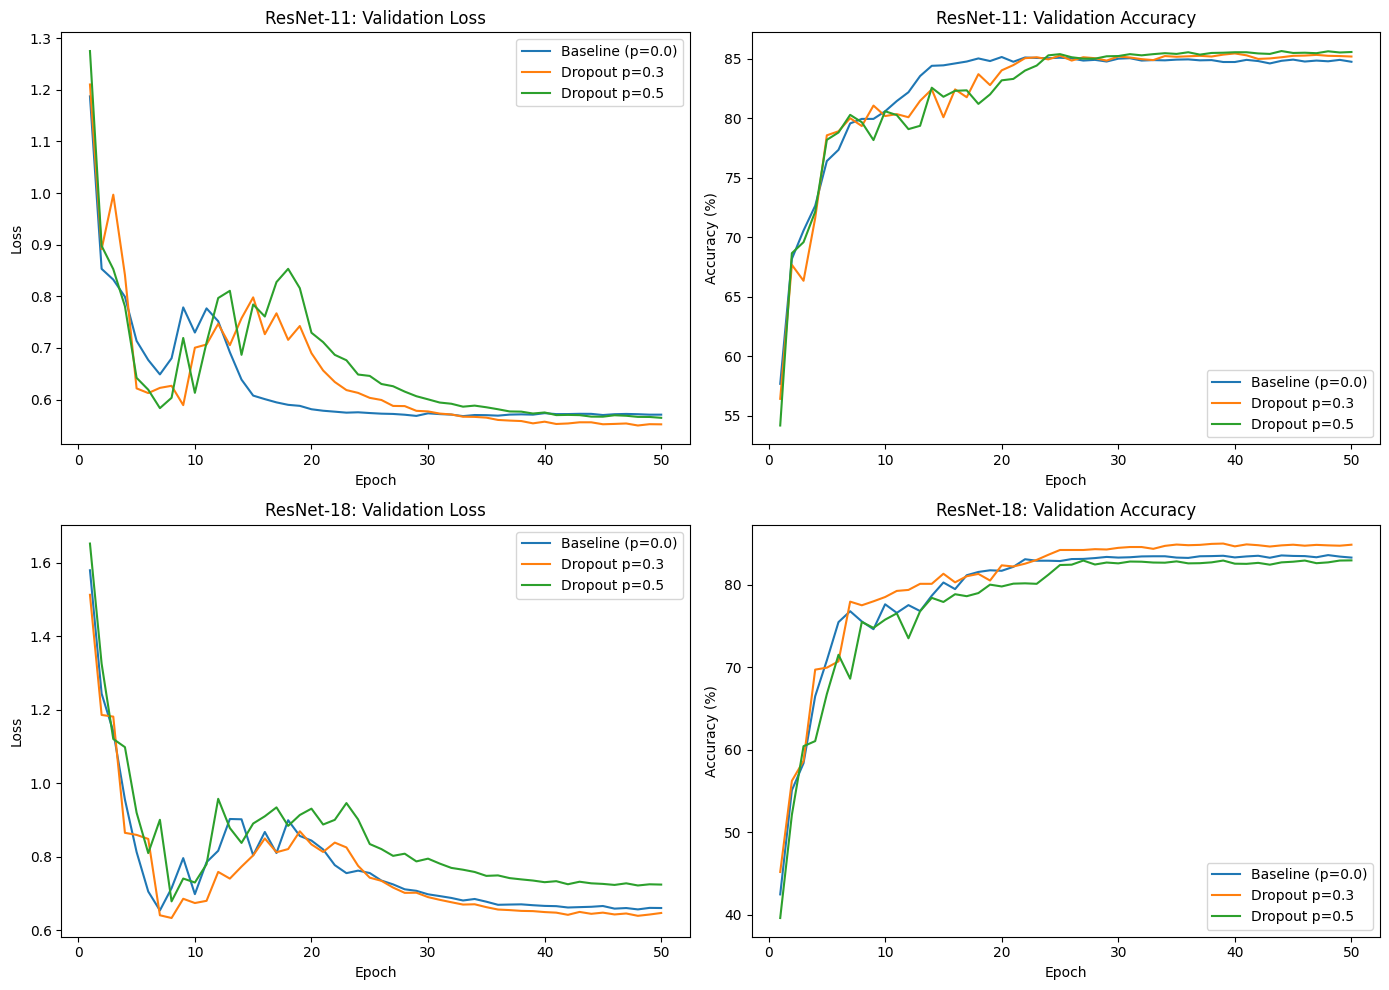

In [ ]:
#Comparison Plots
epochs_50 = range(1, 51)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ResNet-11
axes[0,0].plot(epochs_50, rn11_vl,    label='Baseline (p=0.0)')
axes[0,0].plot(epochs_50, rn11_vl_03, label='Dropout p=0.3')
axes[0,0].plot(epochs_50, rn11_vl_05, label='Dropout p=0.5')
axes[0,0].set_title('ResNet-11: Validation Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()

# ResNet-11
axes[0,1].plot(epochs_50, rn11_va,    label='Baseline (p=0.0)')
axes[0,1].plot(epochs_50, rn11_va_03, label='Dropout p=0.3')
axes[0,1].plot(epochs_50, rn11_va_05, label='Dropout p=0.5')
axes[0,1].set_title('ResNet-11: Validation Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy (%)')
axes[0,1].legend()

# ResNet-18
axes[1,0].plot(epochs_50, rn18_vl,    label='Baseline (p=0.0)')
axes[1,0].plot(epochs_50, rn18_vl_03, label='Dropout p=0.3')
axes[1,0].plot(epochs_50, rn18_vl_05, label='Dropout p=0.5')
axes[1,0].set_title('ResNet-18: Validation Loss')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()

# ResNet-18
axes[1,1].plot(epochs_50, rn18_va,    label='Baseline (p=0.0)')
axes[1,1].plot(epochs_50, rn18_va_03, label='Dropout p=0.3')
axes[1,1].plot(epochs_50, rn18_va_05, label='Dropout p=0.5')
axes[1,1].set_title('ResNet-18: Validation Accuracy')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy (%)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('resnet_dropout_comparison.png', dpi=150)
plt.show()

In [ ]:
#Accuracy
rn11_acc_base = evaluate(rn11_baseline, test_loader)
rn11_acc_d03  = evaluate(rn11_d03,      test_loader)
rn11_acc_d05  = evaluate(rn11_d05,      test_loader)
rn18_acc_base = evaluate(rn18_baseline, test_loader)
rn18_acc_d03  = evaluate(rn18_d03,      test_loader)
rn18_acc_d05  = evaluate(rn18_d05,      test_loader)

print("ResNet-11:")
print(f"  Baseline (p=0.0): {rn11_acc_base:.2f}%")
print(f"  Dropout  (p=0.3): {rn11_acc_d03:.2f}%")
print(f"  Dropout  (p=0.5): {rn11_acc_d05:.2f}%")
print("\nResNet-18:")
print(f"  Baseline (p=0.0): {rn18_acc_base:.2f}%")
print(f"  Dropout  (p=0.3): {rn18_acc_d03:.2f}%")
print(f"  Dropout  (p=0.5): {rn18_acc_d05:.2f}%")

ResNet-11:
  Baseline (p=0.0): 84.13%
  Dropout  (p=0.3): 84.81%
  Dropout  (p=0.5): 85.21%

ResNet-18:
  Baseline (p=0.0): 82.92%
  Dropout  (p=0.3): 83.98%
  Dropout  (p=0.5): 81.94%


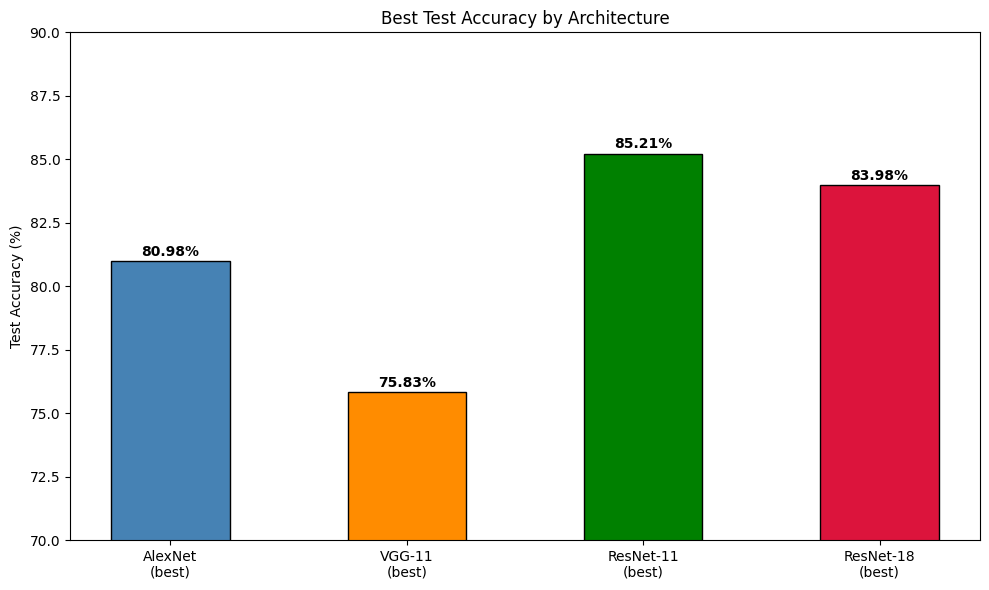


Model            Params(M)   Best Acc   Time/Epoch
AlexNet (best)       10.18     80.98%        21.4s
VGG-11 (best)        18.14     75.83%        19.1s
ResNet-11 (best)       6.57     85.21%        25.7s
ResNet-18 (best)      11.17     83.98%        40.5s


In [ ]:
#Full Comparison
models      = ['AlexNet\n(best)', 'VGG-11\n(best)', 'ResNet-11\n(best)', 'ResNet-18\n(best)']
params      = [10.18, 18.14, 6.57, 11.17]
best_accs   = [
    80.98,
    75.83,
    max(rn11_acc_base, rn11_acc_d03, rn11_acc_d05),
    max(rn18_acc_base, rn18_acc_d03, rn18_acc_d05)
]
train_times = [21.4, 19.1, rn11_time, rn18_time]

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, best_accs, color=['steelblue','darkorange','green','crimson'],
              width=0.5, edgecolor='black')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Best Test Accuracy by Architecture')
ax.set_ylim(70, 90)
for bar, acc in zip(bars, best_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison_bar.png', dpi=150)
plt.show()

# Summary table
print("\n" + "=" * 65)
print(f"{'Model':<15} {'Params(M)':>10} {'Best Acc':>10} {'Time/Epoch':>12}")
print("=" * 65)
for m, p, a, t in zip(models, params, best_accs, train_times):
    print(f"{m.replace(chr(10),' '):<15} {p:>10.2f} {a:>9.2f}% {t:>11.1f}s")
print("=" * 65)